The problem with the approach we used earlier is that if we are to take more context into account when predicting the next char in a sequence things quickly blow up and the size of P table exponentially grows with the length of the context.When we take 2 chars and try to predict the third char the number of rows in our matrix will be 27x27.
The matrix has 27×27 rows because each row corresponds to a unique ordered pair of characters, and each character can independently take 27 possible values.
That why we are going to implement MLP to predict the next char in a sequence.

# **Bengio et al. 2003 MLP language model paper**
Let’s keep in mind that we are building a character-level language model. In this paper, however, the authors use a vocabulary of 17K possible words and build a word-level language model. We will instead apply their approach at the character level.

In the paper, they propose taking each of these 17K words and associating it with a 30-dimensional feature vector, so every word is embedded into a 30-dimensional space. These embeddings are learned through backpropagation. As a result, words with similar meanings or multiple senses may end up close to each other in this space, while words with very different meanings will be far apart.

Suppose we are trying to predict the sentence
“A dog was running in a …”
and assume that this exact phrase has never appeared in the training data, meaning it is out of distribution. Even so, this approach allows the model to make a reasonable prediction, because it may have seen similar phrases or contexts during training.

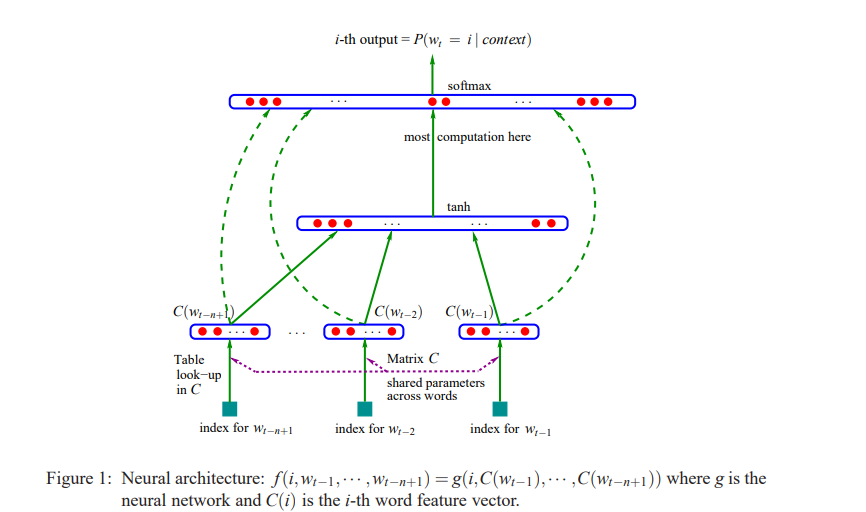

We take the three previous words and try to predict the fourth word in the sequence. Each word is represented by a 30-dimensional embedding, so the input layer consists of 30 neurons per word, for a total of 90 input neurons.

Next comes the hidden layer of the neural network. The size of this layer is a hyperparameter. For example, if the hidden layer has 100 neurons, then each of these neurons is fully connected to all 90 input neurons. There is tanh non linearity.

Next comes the output layer. Since there are 17,000 possible words that could come next, this layer contains 17,000 neurons. Each output neuron is fully connected to all neurons in the hidden layer and represents the score (or logit) for a particular word in the vocabulary.

On top of that, we apply a softmax layer. Each of these logits is exponentiated, and then all values are normalized so that they sum to 1. This gives us a valid probability distribution over all possible next words in the sequence.

# **Building makemore MLP**

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [6]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], [] # X is the input to the neural net and the Y are the labels for each example inside X
for w in words[:5]:

  print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [8]:
# Frome 5 words we created 32 examples and each input to the neural net is 3 integers and we have a label that is also an integer
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [9]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [10]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

Let’s now build a neural network that takes the inputs X and predicts the targets Y.
The first component of this network is the embedding lookup table, denoted by C. We have 27 possible characters and we want to embed them into a lower-dimensional space.

In the paper, they have 17,000 words and embed each word into a 30-dimensional vector.

In our case, we will embed each character into a 2-dimensional vector.

In [11]:
C = torch.randn((27, 2))

In [12]:
C

tensor([[ 0.8364,  0.3517],
        [-1.4364, -0.0381],
        [ 2.2601,  1.5304],
        [ 1.1818, -1.6643],
        [ 1.9219, -0.1954],
        [-1.0297,  0.3967],
        [ 0.3685, -0.3857],
        [-0.9681, -0.5137],
        [-0.8779,  0.5895],
        [-1.5946, -1.7694],
        [ 0.1625,  0.4566],
        [ 1.7714,  0.4680],
        [ 0.5264, -1.7801],
        [-1.7056, -0.0132],
        [ 1.5695,  0.3855],
        [ 1.4423, -0.2888],
        [ 0.3568, -0.6604],
        [ 1.6111,  1.1520],
        [-0.7785,  1.8996],
        [ 1.4606, -0.9106],
        [-0.1164, -0.3710],
        [-1.3734, -0.6314],
        [ 0.1750,  0.8844],
        [ 0.1957,  0.2379],
        [-0.3244, -1.0352],
        [-0.9548, -0.4965],
        [ 0.3045,  0.1590]])

In [13]:
C[5]

tensor([-1.0297,  0.3967])

In [14]:
F.one_hot(torch.tensor(5), num_classes=27)

tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

In [15]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C # one_hot dtype is long

tensor([-1.0297,  0.3967])

In [16]:
C[([5, 6, 7, 7, 7])]

tensor([[-1.0297,  0.3967],
        [ 0.3685, -0.3857],
        [-0.9681, -0.5137],
        [-0.9681, -0.5137],
        [-0.9681, -0.5137]])

In [17]:
C[X].shape # (32, 3) is the original shape and for every one of those 32 by 3 integers we have retrieved the embedding vector

torch.Size([32, 3, 2])

In [18]:
X[13, 2]

tensor(1)

In [19]:
C[X][13, 2]

tensor([-1.4364, -0.0381])

In [20]:
C[1]

tensor([-1.4364, -0.0381])

In [21]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [22]:
W1 = torch.randn((6, 100))  # 3 x 2 and number of neurons 100 in hidden layer (hyperparameter)
b1 = torch.randn(100)

In [23]:
emb @ W1 + b1 # This matrix mul will not work, so we need to concat inputs together somehow

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [24]:
emb[:, 0, :].shape

torch.Size([32, 2])

In [25]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape # This code would not generalize if we to change the block size later

torch.Size([32, 6])

In [26]:
len(torch.unbind(emb, 1))

3

In [27]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

In [28]:
# More efficient way to do the same
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [29]:
a.shape

torch.Size([18])

In [30]:
a.view(9, 2)

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]])

In [31]:
a.view(3, 3, 2) # as long as the total num of elements mul to be the same

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [32]:
# In PyTorch view is efficient, because there is smth called the underlying storage

a.storage() # This is how a tensor is represented in the computer memory it's always a 1 dim vector

/tmp/ipython-input-2216357215.py:3: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage() # This is how a tensor is represented in the computer memory it's always a 1 dim vector


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

When we call view(), we are manipulating the metadata of the tensor—specifically, the attributes that define how a 1-dimensional sequence of values is interpreted as an n-dimensional tensor.

What’s important is that no memory is changed, copied, moved, or newly created when we call view(). The underlying storage remains exactly the same; only the way the tensor is viewed is modified.

In [33]:
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [34]:
# Now it will work
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)   # emb.view(-1, 6) @ W1 + b1 same res

In [35]:
h

tensor([[-0.9901,  0.9207, -0.9541,  ..., -0.8354, -0.9998, -0.9990],
        [-0.9163, -0.4033, -0.1052,  ..., -0.9018, -1.0000, -0.9762],
        [ 0.8823, -0.3707,  0.9718,  ..., -0.9780, -0.9953,  0.9310],
        ...,
        [-0.8757, -0.7024,  0.9365,  ..., -0.8081, -1.0000, -0.8174],
        [ 0.9787, -0.9332,  0.9954,  ...,  0.6754, -0.8710,  0.9893],
        [ 0.9900,  0.9974,  0.9932,  ...,  0.9856,  0.9440,  1.0000]])

In [36]:
h.shape

torch.Size([32, 100])

In [37]:
# Now let's build last layer
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [38]:
logits = h @ W2 + b2

In [39]:
logits.shape

torch.Size([32, 27])

In [40]:
counts = logits.exp()

In [41]:
prob = counts / counts.sum(1, keepdims=True)

In [42]:
prob.shape

torch.Size([32, 27])

In [43]:
prob[0].sum()

tensor(1.)

Now we would like to index into the rows of prob and in each row we'd like to pluck out prob assigned to the correct char.

In [44]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [45]:
prob[torch.arange(32), Y] # This gives the current probs as assigned by this neural net and we have not trained this neural net yet

tensor([3.4240e-10, 3.5165e-04, 2.4051e-08, 1.3907e-04, 4.5199e-04, 3.5312e-04,
        8.9588e-04, 1.1704e-06, 1.7987e-08, 9.0450e-01, 5.7207e-04, 9.9791e-01,
        6.9997e-05, 1.4324e-06, 3.9428e-02, 8.0355e-06, 9.6410e-09, 8.2268e-11,
        6.5968e-03, 3.6996e-14, 1.5826e-10, 1.1968e-08, 1.0000e+00, 3.4745e-08,
        4.1606e-11, 1.4582e-10, 1.6717e-06, 5.4251e-07, 3.4225e-07, 7.7889e-10,
        1.4666e-03, 7.7248e-01])

In [46]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(12.7632)

In [47]:
# ------------ now made respectable :) ---------------

In [48]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [49]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [50]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [51]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(17.7697)

In [52]:
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdims=True)
# loss = -prob[torch.arange(32), Y].log().mean()
# Instead of this we can do the same loss = F.cross_entropy(logits, Y) this is more efficient in PyTorch

In [53]:
for p in parameters:
  p.requires_grad = True

In [54]:
for _ in range(100):

  # forward pass
  emb = C[X] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y)

  print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  for p in parameters:
    p.data += -0.1 * p.grad

17.76971435546875
13.656401634216309
11.298768997192383
9.452455520629883
7.984262466430664
6.891321182250977
6.100015163421631
5.452036380767822
4.8981523513793945
4.4146647453308105
3.985849142074585
3.6028313636779785
3.262141704559326
2.961380958557129
2.6982977390289307
2.469712972640991
2.271660566329956
2.101283550262451
1.9571772813796997
1.8374857902526855
1.7380964756011963
1.6535115242004395
1.579089879989624
1.5117665529251099
1.4496047496795654
1.3913121223449707
1.3359923362731934
1.2830528020858765
1.2321909666061401
1.1833815574645996
1.1367987394332886
1.0926642417907715
1.0510926246643066
1.0120267868041992
0.9752707481384277
0.9405564069747925
0.9076125025749207
0.876192033290863
0.8460890650749207
0.8171358108520508
0.7891990542411804
0.762174665927887
0.7359814047813416
0.7105578184127808
0.6858609914779663
0.6618651151657104
0.638565719127655
0.6159818768501282
0.5941659212112427
0.573210597038269
0.5532563924789429
0.5344881415367126
0.5171169638633728
0.50133132

Now we are overfitting, because we have 32 examples from 5 words and therefore it's easy to make this neural net fit only this 32 examples. So in this case we have few examples and many parameters.

# **Now let's read in the full dataset and optimize the neural net**

In [55]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], [] # X is the input to the neural net and the Y are the labels for each example inside X
for w in words:

  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [56]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [57]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [58]:
for p in parameters:
  p.requires_grad = True

In [59]:
for _ in range(100):

  # forward pass
  emb = C[X] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y)

  print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  for p in parameters:
    p.data += -0.1 * p.grad

19.505229949951172
17.084495544433594
15.776531219482422
14.833340644836426
14.002602577209473
13.253260612487793
12.57991886138916
11.983101844787598
11.47049331665039
11.05185604095459
10.709586143493652
10.407632827758789
10.127808570861816
9.864365577697754
9.614503860473633
9.376440048217773
9.148944854736328
8.931111335754395
8.7222318649292
8.521750450134277
8.329227447509766
8.144326210021973
7.966792106628418
7.796451091766357
7.633185863494873
7.476907730102539
7.327521800994873
7.1848859786987305
7.048791885375977
6.918952465057373
6.795018196105957
6.6766037940979
6.563318729400635
6.454789161682129
6.350668907165527
6.250643253326416
6.1544318199157715
6.061785697937012
5.972482681274414
5.886327743530273
5.803146839141846
5.722784042358398
5.64509391784668
5.5699462890625
5.497213840484619
5.4267802238464355
5.3585357666015625
5.2923760414123535
5.228203773498535
5.165928363800049
5.105468273162842
5.04674768447876
4.98969841003418
4.934261322021484
4.880379676818848
4.82

Now we see that training goes slow, in practice people do it with mini batches. We want to randomly select some protion of the dataset and that's a mini batch, and then only forward backward and update on that mini batch and then we iterate on those mini batches

In [60]:
for _ in range(100):
  # mini batch construct
  ix = torch.randint(0, X.shape[0], (32,))
  # forward pass
  emb = C[X[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])

  print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  for p in parameters:
    p.data += -0.1 * p.grad

3.525956630706787
3.439211130142212
3.166400194168091
3.4398250579833984
3.347322702407837
4.376457214355469
3.1472747325897217
3.467606782913208
3.6632080078125
3.2837963104248047
4.513421058654785
3.9971818923950195
3.2018866539001465
2.936598300933838
2.9892959594726562
3.347606897354126
3.057422637939453
3.075575590133667
2.931931734085083
3.679910659790039
3.393587589263916
3.357855796813965
3.290553092956543
3.922351360321045
3.290220260620117
3.042635679244995
3.967524290084839
4.252743721008301
3.5606260299682617
2.907984733581543
3.081868886947632
3.143535614013672
3.9191105365753174
3.4619662761688232
4.151330947875977
3.1475770473480225
3.050844669342041
3.1274168491363525
3.033392906188965
3.1484062671661377
3.5693881511688232
3.7066478729248047
4.308032035827637
3.0592539310455322
3.657566785812378
3.469860315322876
3.351123809814453
4.013922691345215
3.1590962409973145
3.0945146083831787
3.1572952270507812
2.8941023349761963
3.2696471214294434
4.00059700012207
3.896109580

In [61]:
torch.randint(0, X.shape[0], (32,))

tensor([133942,  62422, 210697,  96645, 122111,  92973, 199458, 130310,  40096,
         64802, 105692, 208831,  58671, 184929, 115174,  25835, 176322,  28427,
        181512, 187498,  63710,  97048, 168815, 156086, 192280, 153213, 205874,
         51535, 164988,  87110, 159208,  24284])

Because we are only working with mini-batches, the quality of our gradient estimate is lower. The direction we get is therefore noisier and not the exact gradient of the full dataset.

However, this approximate gradient is usually good enough—even when it is estimated from as few as 32 examples. In practice, it is far more effective to take many small steps using noisy gradients than to compute the exact gradient and take only a few expensive steps.

In [62]:
for _ in range(1000):
  # mini batch construct
  ix = torch.randint(0, X.shape[0], (32,))
  # forward pass
  emb = C[X[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  for p in parameters:
    p.data += -0.1 * p.grad
print(loss.item())

2.8052926063537598


# **How to determine learning rate?**

In [98]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], [] # X is the input to the neural net and the Y are the labels for each example inside X
for w in words:

  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [99]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [100]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [101]:
for p in parameters:
  p.requires_grad = True

In [80]:
for _ in range(100):
  # mini batch construct
  ix = torch.randint(0, X.shape[0], (32,))
  # forward pass
  emb = C[X[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  for p in parameters:
    p.data += -0.001 * p.grad
print(loss.item())

10.40646743774414
13.402819633483887
12.134572982788086
9.913045883178711
9.205516815185547
10.417052268981934
8.764142990112305
10.446784019470215
10.923154830932617
10.034933090209961
13.169068336486816
11.51996898651123
10.475194931030273
13.344532012939453
11.704257011413574
10.951737403869629
10.968390464782715
9.809496879577637
10.761954307556152
11.22484016418457
12.347013473510742
10.50784969329834
12.80751895904541
11.548270225524902
14.773954391479492
11.444184303283691
13.41215991973877
11.566458702087402
9.587884902954102
10.156950950622559
13.716617584228516
8.731528282165527
10.944942474365234
9.157777786254883
10.19130802154541
10.604720115661621
9.670336723327637
9.19186019897461
13.485452651977539
10.49331283569336
10.664695739746094
9.063720703125
12.706754684448242
9.749786376953125
10.631723403930664
8.338375091552734
12.829763412475586
12.316963195800781
10.5372314453125
9.700136184692383
9.835700988769531
12.043258666992188
10.67984676361084
12.441444396972656
9.1

We see that the right lr is somewhere between -0.001 and -1

In [83]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [91]:
lri = []
lossi = []
for i in range(1000):
  # mini batch construct
  ix = torch.randint(0, X.shape[0], (32,))
  # forward pass
  emb = C[X[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad
  # track stats
  lri.append(lre[i])
  lossi.append(loss.item())

#print(loss.item())

9.424500465393066
8.960382461547852
9.764361381530762
7.575626850128174
8.01047420501709
6.184731960296631
8.291571617126465
7.580130100250244
8.994301795959473
7.302735805511475
6.596550464630127
8.16937255859375
8.161169052124023
8.844618797302246
7.241098880767822
7.2380828857421875
7.614565849304199
8.129467010498047
9.407927513122559
7.34736442565918
9.376708030700684
9.426850318908691
8.413325309753418
10.559232711791992
9.227113723754883
9.37767505645752
9.409675598144531
8.120173454284668
8.91270637512207
7.921403884887695
8.310661315917969
8.414143562316895
8.128252983093262
7.545424461364746
7.50191593170166
9.442800521850586
8.037503242492676
9.054696083068848
7.845607757568359
7.206783294677734
8.626947402954102
8.2517728805542
6.800365447998047
7.605909824371338
7.018857479095459
7.3109025955200195
7.819682598114014
8.405172348022461
6.971674919128418
7.836564064025879
8.31668472290039
8.187549591064453
7.234432220458984
6.373169898986816
6.835539817810059
9.09215259552002

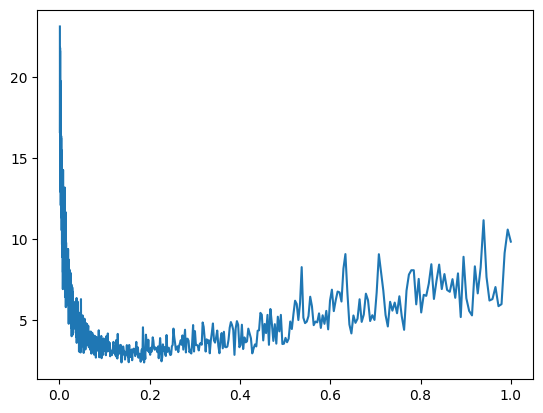

In [90]:
plt.plot(lri, lossi)

Now we see that when we have low lr-s barely anything happens and then as we increase the lr enough we get kind of unstable losses.

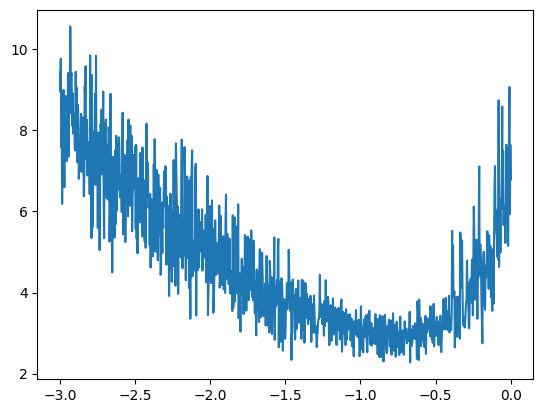

In [92]:
plt.plot(lri, lossi)

10 to the -1 is actually a good lr = 0.1

In [106]:
#lri = []
lossi = []
for i in range(10000):
  # mini batch construct
  ix = torch.randint(0, X.shape[0], (32,))
  # forward pass
  emb = C[X[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  #print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  lr = 10**-1
  for p in parameters:
    p.data += -lr * p.grad
  # track stats
  #lri.append(lre[i])
  #lossi.append(loss.item())

print(loss.item())

2.1348936557769775


In [107]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.4295, grad_fn=<NllLossBackward0>)

**Now let's do learning rate decay**

We are going to take our lr and 10x lower it, so if we are at the late stages of training potentially we may want to go a bit slower.

In [108]:
#lri = []
lossi = []
for i in range(10000):
  # mini batch construct
  ix = torch.randint(0, X.shape[0], (32,))
  # forward pass
  emb = C[X[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Y[ix])
  #print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  lr = 0.01
  for p in parameters:
    p.data += -lr * p.grad
  # track stats
  #lri.append(lre[i])
  #lossi.append(loss.item())

print(loss.item())

2.050457239151001


In [109]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.3418, grad_fn=<NllLossBackward0>)

We now have small model with not so much parameters, but as the capacity of neural net grows it becomes more and more capable of overfitting our training set, so loss on the training set will become very very low, but all that model is doing is just memorizing the training data.

The standard in the field is to split up the data into 3 splits - training set, validation set, test set.

Training set → used to fit the model parameters (weights).

Validation set → used during development to choose hyperparameters (LR, batch size, architecture tweaks, early stopping, etc.).

Test set → used once at the very end to report an unbiased estimate of performance.

In [122]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
block_size = 3 # context length: how many characters do we take to predict the next one?
def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [123]:
len(words)

32033

In [124]:
n1

25626

In [125]:
n2

28829

In [126]:
n2 - n1

3203

In [127]:
len(words) - n2

3204

In [128]:
Xtr.shape, Ytr.shape

(torch.Size([182580, 3]), torch.Size([182580]))

In [129]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [130]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [131]:
for p in parameters:
  p.requires_grad = True

In [135]:
#lri = []
lossi = []
for i in range(30000):
  # mini batch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  lr = 0.01
  for p in parameters:
    p.data += -lr * p.grad
  # track stats
  #lri.append(lre[i])
  #lossi.append(loss.item())

print(loss.item())

2.432270050048828


In [136]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3217, grad_fn=<NllLossBackward0>)

**Now we expect to make performance improvements by scaling up the size of this neural net.**

In [143]:
# Let's make hidden layer bigger
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [144]:
sum(p.nelement() for p in parameters) # number of parameters in total

10281

In [145]:
for p in parameters:
  p.requires_grad = True

In [ ]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

In [150]:
lri = []
lossi = []
stepi = []
for i in range(40000):
  # mini batch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  lr = 0.05
  for p in parameters:
    p.data += -lr * p.grad
  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.item())

print(loss.item())

2.4667694568634033


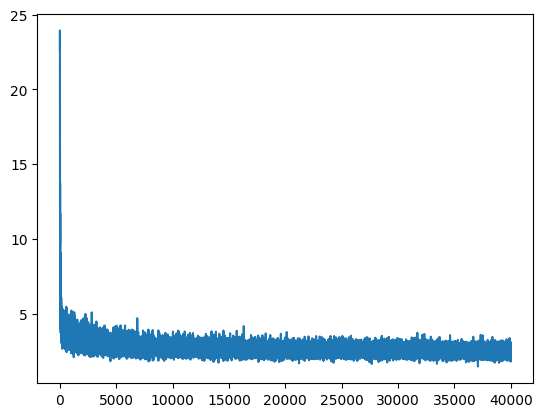

In [147]:
plt.plot(stepi, lossi)

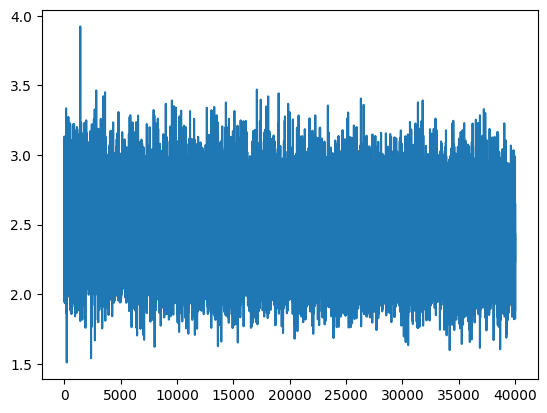

In [149]:
plt.plot(stepi, lossi)

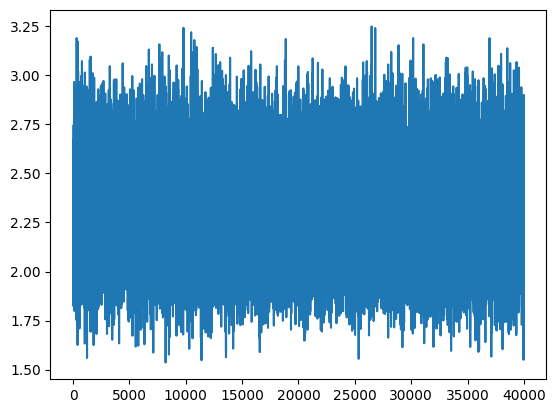

In [151]:
plt.plot(stepi, lossi)

In [152]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3403, grad_fn=<NllLossBackward0>)

We see that after making hidden layer bigger, but still not enough. The bottleneck of the neural net right now are embeddings which are 2 dimensional.

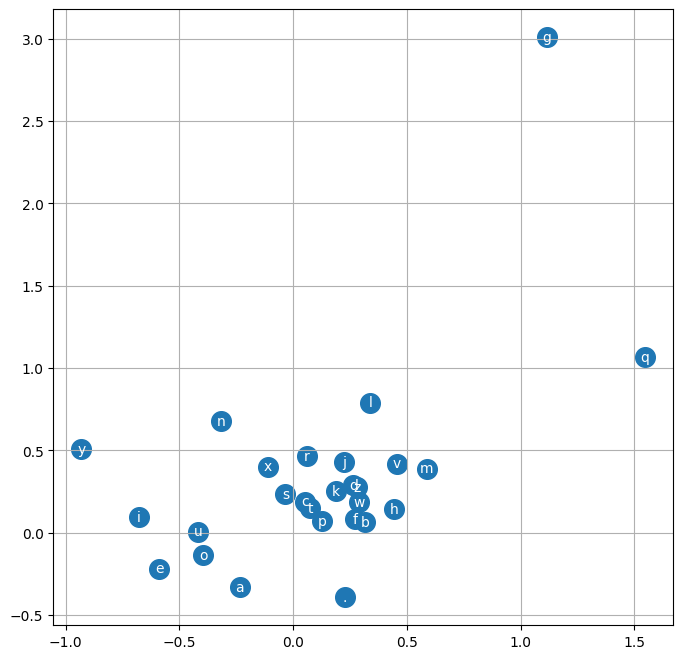

In [153]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')


# **Scaling up embedding size**



In [164]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g) # 3 x 10
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [165]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [167]:
for p in parameters:
  p.requires_grad = True

In [168]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [169]:
lri = []
lossi = []
stepi = []

In [170]:
for i in range(200000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

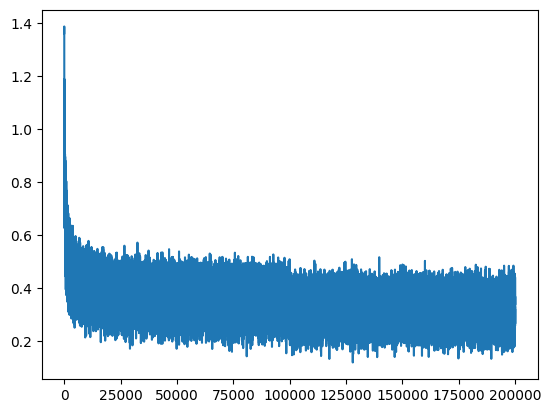

In [171]:
plt.plot(stepi, lossi)

In [172]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1574, grad_fn=<NllLossBackward0>)

So what we have tried to do.


*   Changed the size of hidden layer
*   Scaled up the embedding size

And now we reached 2.15 loss.



# **Sampling from the model**

In [173]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [174]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmah.
ambrillia.
jmlex.
taty.
halaysie.
mahnen.
den.
art.
kaeli.
nellara.
chaiiv.
kaleigh.
ham.
por.
desian.
shon.
emira.
bian.
jero.
dearynix.
